# Laser Step-Down: Global Forward Model

Fits the **entire ~4-day YAW spin-frequency record at once** with a first-order
linear rotor model driven by the measured PD trace:

$$I\,\dot\Omega = -I\gamma\,\Omega + \kappa\,(\mathrm{PD}(t) - \mathrm{PD}_0)$$

with γ **fixed** to the free-decay value measured in `spindown_20260702.ipynb`
(τ = 67.65 min). Unlike the per-step fits in `laser_stepdown_settling.ipynb`, this
uses every transient -- including steps that never settled -- because for a linear
system the full response to a known P(t) is determined by just (Ω₀, κ, PD₀). The
transition overshoots the per-step fits had to dodge are, in this picture, simply
the response to real power transients in the measured PD trace, so they become
usable data rather than a nuisance.

**Power proxy:** the PD trace itself (measured, and the detector should be linear).
The step-down log's mW values are rough -- and visibly not proportional to PD level
across steps -- so κ is extracted in torque per PD count; conversion to N·m/W is
reported only approximately at the end.

**Fitting trick:** the solution is linear in the three unknowns, so no nonlinear
optimizer is needed:

$$f(t) = c_1 e^{-\gamma t} + c_2\, G(t) + c_3\,\frac{1 - e^{-\gamma t}}{\gamma},
\qquad G(t) = \int_0^t e^{-\gamma (t - t')}\,\mathrm{PD}(t')\,dt'$$

with $c_1 = f(0)$, $c_2 = \kappa / (2\pi I)$, $\mathrm{PD}_0 = -c_3 / c_2$.
Plain (robust, iteratively clipped) least squares.

Rotor constants I, r_c are reused read-only from
`momentum-simulation/thermal_noise_spindown.py` -- that model is not modified.

In [1]:
import h5py
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.ndimage import uniform_filter1d

In [2]:
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

PD_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]
YAW_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467582390_1467662710.h5',
]
STEP_TABLE_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'

# Free-decay damping, measured in spindown_20260702.ipynb (PIT channel, fit from the
# post-drive-off peak to the libration onset). FIXED in the model.
TAU_FREE_MIN = 67.65
GAMMA = 1.0 / (TAU_FREE_MIN * 60.0)   # s^-1

# Rotor constants reused READ-ONLY from momentum-simulation/thermal_noise_spindown.py
I_TOTAL = 1.88e-11    # kg m^2, disk + sail
R_C     = 2.625e-3    # m, sail wing center radius
C_LIGHT = 2.998e8     # m/s

# Rough (PD level, ~mW) pairs from the operator's step-down log, used ONLY for the
# approximate N*m/W conversion at the end. Note these are visibly non-monotonic
# (e.g. PD 186 at a LOWER commanded level than PD 167) -- the log mW are rough.
PD_MW_PAIRS = [(240.2, 15.10), (167.3, 12.92), (186.2, 12.23), (160.0, 11.46),
               (114.5, 10.01), (134.7, 8.49), (84.0, 7.09), (67.2, 3.41)]

steps_csv = []
with open(STEP_TABLE_CSV) as fcsv:
    for row in csv.DictReader(fcsv):
        steps_csv.append(row)

# Fit starts where the pre-sequence baseline ends (end of detected step [1]) -- the
# 20+ h before that predates the commanded sequence entirely.
FIT_START_GPS = float([r for r in steps_csv if int(r['step']) == 1][0]['t_end_gps'])
print(f"gamma (fixed) = {GAMMA:.4e} /s   (tau = {TAU_FREE_MIN} min)")
print(f"fit starts at end of pre-sequence: {gps_to_dt(FIT_START_GPS)}")

gamma (fixed) = 2.4637e-04 /s   (tau = 67.65 min)
fit starts at end of pre-sequence: 2026-07-06 19:56:12+00:00


## 1. Load Data
Same loaders and Hilbert pipeline as `laser_stepdown_settling.ipynb` (PD strided to
1 Hz; YAW decimated to 64 Hz, bandpassed 0.02-8 Hz, 30 s-smoothed instantaneous
frequency). The large raw arrays are freed after the frequency extraction to keep
the memory footprint down.

In [3]:
def load_strided_multi(files, stride):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                y_seg = dset[ix: ix + n: stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                t_list.append(t_seg)
                y_list.append(y_seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

def load_channel_multi(files, fs_out=64.0):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                t_list.append(t_seg)
                y_list.append(seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq,     size=win),
            uniform_filter1d(envelope[:-1], size=win),
            dt / 2)

In [4]:
t_pd, y_pd = load_strided_multi(PD_FILES, 1024)   # 1 Hz effective
print(f"PD: {len(y_pd):,} points  {gps_to_dt(t_pd[0])} -> {gps_to_dt(t_pd[-1])}")

FS_RING = 64.0
# F_HIGH = 8 Hz to match laser_stepdown_settling.ipynb: the highest real rotation
# frequency in this run is ~7.1 Hz (step 2's transient spin-up); plateaus top out
# at ~3.87 Hz.
F_LOW, F_HIGH = 0.02, 8.0
SMOOTH_SEC = 30.0

print("Loading YAW at 64 Hz across the full span (takes a few minutes)...")
t_yaw, y_yaw = load_channel_multi(YAW_FILES, fs_out=FS_RING)
sos = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
t_freq_yaw = t_yaw[:-1] + dt_half
del y_yaw, y_yaw_f   # free ~350 MB -- only the frequency series is needed below
print(f"freq range: {freq_yaw.min():.3f} - {freq_yaw.max():.3f} Hz")

PD: 339,520 points  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51+00:00
Loading YAW at 64 Hz across the full span (takes a few minutes)...
freq range: 0.006 - 7.877 Hz


## 2. Common 1 Hz Grid and Validity Mask
Everything is put on the PD trace's 1 Hz time grid, restricted to the fit window.
Points where the Hilbert frequency is below `F_MIN_VALID` are excluded from the fit
(libration-regime / glitch territory where the instantaneous frequency isn't a
trustworthy rotation rate); on top of that, the least-squares step iteratively clips
gross outliers (Hilbert dropout spikes) rather than hand-masking them.

In [5]:
gmask = t_pd >= FIT_START_GPS
t_grid = t_pd[gmask].astype(np.float64)
pd_grid = y_pd[gmask].astype(np.float64)
f_grid = np.interp(t_grid, t_freq_yaw, freq_yaw)
trel = t_grid - t_grid[0]
dt = np.diff(t_grid, prepend=t_grid[0] - 1.0)   # ~1 s, exact per sample

F_MIN_VALID = 0.2   # Hz
valid = f_grid > F_MIN_VALID
print(f"{len(t_grid):,} grid points over {trel[-1]/3600:.1f} h; {valid.sum():,} pass the f > {F_MIN_VALID} Hz mask")

259,720 grid points over 72.1 h; 259,720 pass the f > 0.2 Hz mask


## 3. Fit
Build the three basis functions (the convolution G is computed with an exact
recursive exponential filter, treating PD as piecewise-constant over each 1 s
sample), then robust least squares: fit, clip residuals beyond 5 robust sigma
(MAD-based), refit -- so Hilbert glitch spikes don't drag the solution.

In [6]:
def build_basis(gamma):
    decay = np.exp(-gamma * trel)
    a = np.exp(-gamma * dt)
    G = np.zeros_like(pd_grid)
    for i in range(1, len(G)):
        G[i] = G[i - 1] * a[i] + pd_grid[i] * (1 - a[i]) / gamma
    return np.column_stack([decay, G, (1 - decay) / gamma])

def robust_lstsq(B, y, sel0, n_iter=3, clip=5.0):
    sel = sel0.copy()
    coef = None
    for _ in range(n_iter):
        coef, *_ = np.linalg.lstsq(B[sel], y[sel], rcond=None)
        resid = y - B @ coef
        r = resid[sel]
        sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
        newsel = sel0 & (np.abs(resid) < clip * sigma)
        if (newsel == sel).all():
            break
        sel = newsel
    return coef, sel, resid

B = build_basis(GAMMA)
coef, sel, resid = robust_lstsq(B, f_grid, valid)
c1, c2, c3 = coef
f_model = B @ coef
rms = resid[sel].std()

kappa_pd = 2 * np.pi * I_TOTAL * c2    # N*m per PD count
PD0 = -c3 / c2
print(f"c1 (f at fit start)     = {c1:.4f} Hz")
print(f"kappa                   = {kappa_pd:.4e} N*m per PD count")
print(f"PD0 (zero-torque PD)    = {PD0:.2f} counts   (pre-sequence PD level was ~14)")
print(f"residual RMS            = {rms:.4f} Hz  ({sel.sum():,} of {valid.sum():,} valid points kept)")

c1 (f at fit start)     = 2.0833 Hz
kappa                   = 7.3499e-16 N*m per PD count
PD0 (zero-torque PD)    = 19.48 counts   (pre-sequence PD level was ~14)
residual RMS            = 0.1962 Hz  (252,420 of 259,720 valid points kept)


## 4. Does the Whole Dataset Prefer the Free-Decay γ?
Repeat the fit on a grid of assumed τ values and plot residual RMS vs τ. If the
4-day record is well described by linear drag, the minimum should sit near the
independently measured free-decay value (67.65 min). This is the global version of
the per-step "float τ vs τ_free" comparison in the settling notebook's Section 6.

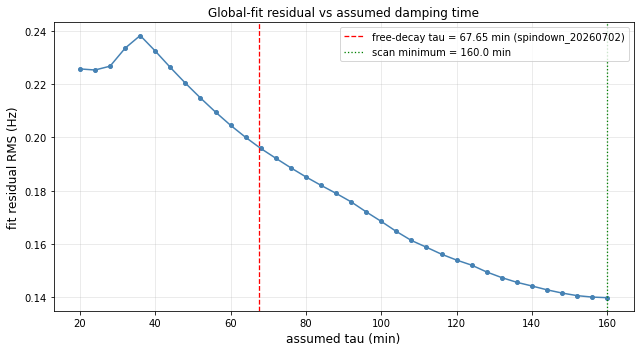

scan minimum at tau = 160.0 min vs free-decay 67.65 min


In [7]:
taus_scan = np.linspace(20, 160, 36)   # minutes
rms_scan = []
for tm in taus_scan:
    g = 1.0 / (tm * 60.0)
    Bg = build_basis(g)
    cg, selg, residg = robust_lstsq(Bg, f_grid, valid)
    rms_scan.append(residg[selg].std())
rms_scan = np.array(rms_scan)
best_tau = taus_scan[np.argmin(rms_scan)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(taus_scan, rms_scan, 'o-', ms=4, color='steelblue')
ax.axvline(TAU_FREE_MIN, color='red', ls='--', lw=1.3,
           label=f'free-decay tau = {TAU_FREE_MIN} min (spindown_20260702)')
ax.axvline(best_tau, color='green', ls=':', lw=1.3,
           label=f'scan minimum = {best_tau:.1f} min')
ax.set_xlabel('assumed tau (min)', fontsize=12)
ax.set_ylabel('fit residual RMS (Hz)', fontsize=12)
ax.set_title('Global-fit residual vs assumed damping time')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"scan minimum at tau = {best_tau:.1f} min vs free-decay 67.65 min")

## 5. Model vs Data Across the Full Run

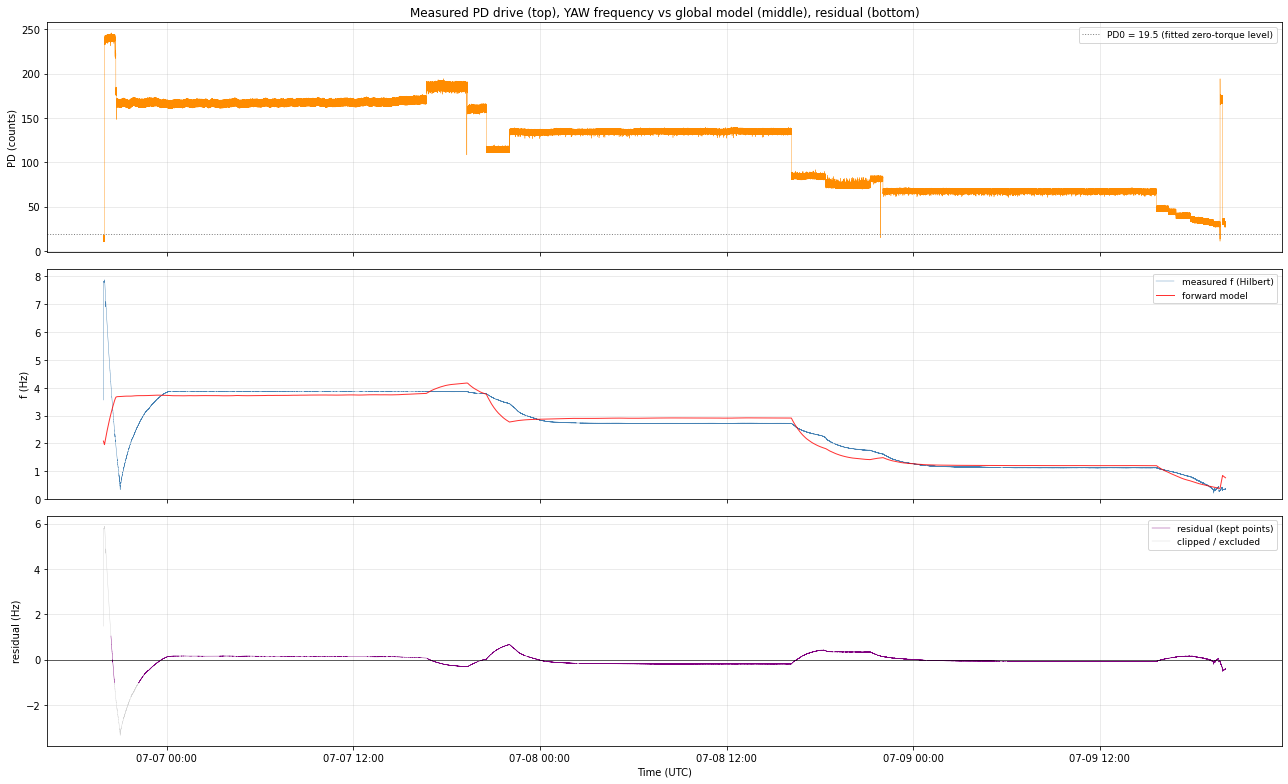

In [8]:
dts = [gps_to_dt(t) for t in t_grid]

fig, axes = plt.subplots(3, 1, figsize=(18, 11), sharex=True)

axes[0].plot(dts, pd_grid, lw=0.4, color='darkorange')
axes[0].axhline(PD0, color='gray', ls=':', lw=1, label=f'PD0 = {PD0:.1f} (fitted zero-torque level)')
axes[0].set_ylabel('PD (counts)')
axes[0].set_title('Measured PD drive (top), YAW frequency vs global model (middle), residual (bottom)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(dts, f_grid, lw=0.4, color='steelblue', label='measured f (Hilbert)')
axes[1].plot(dts, f_model, lw=1.0, color='red', alpha=0.8, label='forward model')
axes[1].set_ylabel('f (Hz)')
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

resid_plot = np.where(sel, resid, np.nan)
axes[2].plot(dts, resid_plot, lw=0.4, color='purple', label='residual (kept points)')
axes[2].plot(dts, np.where(~sel & valid, resid, np.nan), lw=0.4, color='lightgray',
             label='clipped / excluded')
axes[2].axhline(0, color='black', lw=0.6)
axes[2].set_ylabel('residual (Hz)')
axes[2].set_xlabel('Time (UTC)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

plt.tight_layout()
plt.show()

## 6. Validation: Per-Step f_ss vs the Global Model's Steady-State Line
The model predicts a single straight line f_ss = κ(PD - PD₀)/(2πIγ). The per-step
f_ss values from the settling notebook -- tail medians (circles) and, where
available, the fixed-γ extrapolations from its Section 6 (squares) -- should fall
on it if one linear model really describes every step.

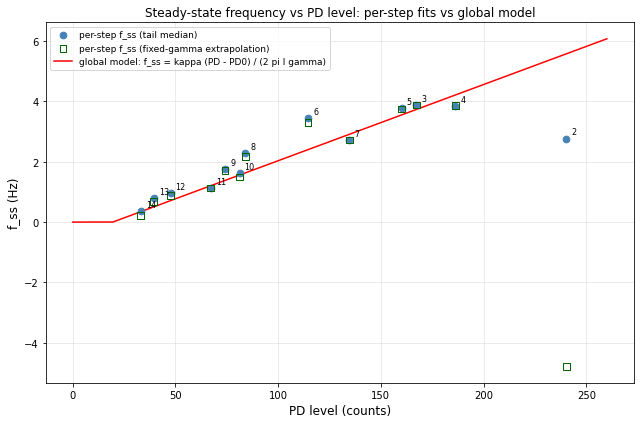

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter([], [], marker='o', s=45, color='steelblue', label='per-step f_ss (tail median)')
ax.scatter([], [], marker='s', s=45, facecolors='none', edgecolors='darkgreen',
           label='per-step f_ss (fixed-gamma extrapolation)')

for row in steps_csv:
    if not row['f_ss_hz']:
        continue
    st, pdl = int(row['step']), float(row['pd_level'])
    ax.scatter(pdl, float(row['f_ss_hz']), marker='o', s=45, color='steelblue', zorder=3)
    fsfx = row.get('f_ss_fixed_gamma_hz', '')
    if fsfx:
        ax.scatter(pdl, float(fsfx), marker='s', s=45, facecolors='none',
                   edgecolors='darkgreen', zorder=3)
    ax.annotate(str(st), (pdl, float(row['f_ss_hz'])), textcoords='offset points',
                xytext=(5, 4), fontsize=8)

pd_line = np.linspace(0, 260, 200)
ax.plot(pd_line, np.clip(c2 * (pd_line - PD0) / GAMMA, 0, None), 'r-', lw=1.5,
        label='global model: f_ss = kappa (PD - PD0) / (2 pi I gamma)')
ax.set_xlabel('PD level (counts)', fontsize=12)
ax.set_ylabel('f_ss (Hz)', fontsize=12)
ax.set_title('Steady-state frequency vs PD level: per-step fits vs global model')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.5 Tail Micro-Step Response: the Low-Power Sensitivity Test
After step 11 (1000 counts), the operator stepped through many closely-spaced
low-power levels -- spacings of ~1-10 PD counts, holds of ~15-30 min -- which the
settling notebook's plateau detection merges or drops (spacing below its level
tolerance, holds below its duration floor). The forward model needs **no step
detection at all**: it is driven by the measured PD trace sample-by-sample, so its
prediction includes the response to every micro-step automatically.

This section zooms into the tail, detects the fine PD levels with a dedicated
2-min-median pass (independent of the main step table), and asks: is the measured
frequency response to each micro-transition visible above the local noise, and does
it match the model's prediction Δf_ss = κ·ΔPD/(2πIγ)? This is the direct empirical
test of sensitivity at the ~0.1 mW scale. (Caveat: the frequency readout degrades
below ~0.2 Hz -- the F_MIN_VALID mask applies here too, so the very lowest levels
may be power-resolvable but frequency-blind.)

In [10]:
# Tail window: from just before step 11's plateau end to the end of the data
STEP11_END = float([r for r in steps_csv if int(r['step']) == 11][0]['t_end_gps'])
TAIL0 = STEP11_END - 1800   # include the last 30 min of step 11 for context

tm = t_grid >= TAIL0
t_tail, pd_tail, f_tail_d, fm_tail = t_grid[tm], pd_grid[tm], f_grid[tm], f_model[tm]
res_tail = np.where(sel[tm], resid[tm], np.nan)
dts_tail = [gps_to_dt(t) for t in t_tail]

# -- Fine level detection: 2-min medians, group while within 1.0 count -------------
BIN_S = 120
bidx = ((t_tail - t_tail[0]) // BIN_S).astype(int)
lv_t, lv_med = [], []
for b in range(bidx.max() + 1):
    m = bidx == b
    if m.sum() > 30:
        lv_t.append(t_tail[m].mean())
        lv_med.append(np.median(pd_tail[m]))
lv_t, lv_med = np.array(lv_t), np.array(lv_med)

fine_levels = []
cur = [0]
for j in range(1, len(lv_med)):
    if abs(lv_med[j] - np.median(lv_med[cur])) < 1.0:
        cur.append(j)
    else:
        if len(cur) >= 5:   # >= 10 min
            fine_levels.append(dict(pd=np.median(lv_med[cur]),
                                     t0=lv_t[cur[0]] - BIN_S/2, t1=lv_t[cur[-1]] + BIN_S/2))
        cur = [j]
if len(cur) >= 5:
    fine_levels.append(dict(pd=np.median(lv_med[cur]), t0=lv_t[cur[0]] - BIN_S/2,
                             t1=lv_t[cur[-1]] + BIN_S/2))

# Local frequency-noise reference: std of 600 s block means of the model residual
# within step 11's settled portion (the quiet region just before the tail)
q = (t_grid >= STEP11_END - 4 * 3600) & (t_grid < STEP11_END) & sel
rq = resid[q]
nb6 = len(rq) // 600
sigma_f_600 = rq[:nb6 * 600].reshape(nb6, 600).mean(axis=1).std() if nb6 >= 3 else np.nan

print(f"{len(fine_levels)} fine PD levels detected in the tail (>= 10 min each):\n")
print(f"{'level':>5} | {'PD':>7} | {'start (UTC)':>11} | {'dur (min)':>9} | {'dPD from prev':>13} | "
      f"{'pred dOmega f_ss (Hz)':>21} | {'vs 5x noise':>11}")
prev_pd = None
for k, lv in enumerate(fine_levels):
    dpd = (lv['pd'] - prev_pd) if prev_pd is not None else np.nan
    pred_dfss = c2 * dpd / GAMMA if prev_pd is not None else np.nan
    if prev_pd is None:
        verdict = "--"
    else:
        verdict = "DETECTABLE" if abs(pred_dfss) > 5 * sigma_f_600 else "below"
    print(f"{k:>5} | {lv['pd']:>7.2f} | {gps_to_dt(lv['t0']).strftime('%H:%M'):>11} | "
          f"{(lv['t1']-lv['t0'])/60:>9.0f} | {dpd:>13.2f} | {pred_dfss:>21.4f} | {verdict:>11}")
    prev_pd = lv['pd']
print(f"\n(5x noise reference: 5 * sigma_f(600 s) = {5*sigma_f_600:.4f} Hz, measured from "
      f"step 11's settled residual)")

9 fine PD levels detected in the tail (>= 10 min each):

level |      PD | start (UTC) | dur (min) | dPD from prev | pred dOmega f_ss (Hz) | vs 5x noise
    0 |   67.05 |       15:06 |        32 |           nan |                   nan |          --
    1 |   47.72 |       15:38 |        46 |        -19.33 |               -0.4881 |  DETECTABLE
    2 |   44.10 |       16:24 |        30 |         -3.62 |               -0.0915 |  DETECTABLE
    3 |   39.47 |       16:54 |        54 |         -4.62 |               -0.1168 |  DETECTABLE
    4 |   35.24 |       17:48 |        34 |         -4.23 |               -0.1069 |  DETECTABLE
    5 |   34.21 |       18:22 |        18 |         -1.03 |               -0.0261 |  DETECTABLE
    6 |   33.05 |       18:40 |        22 |         -1.16 |               -0.0293 |  DETECTABLE
    7 |   31.89 |       19:02 |        16 |         -1.16 |               -0.0294 |  DETECTABLE
    8 |   30.16 |       19:18 |        26 |         -1.73 |               -0.04

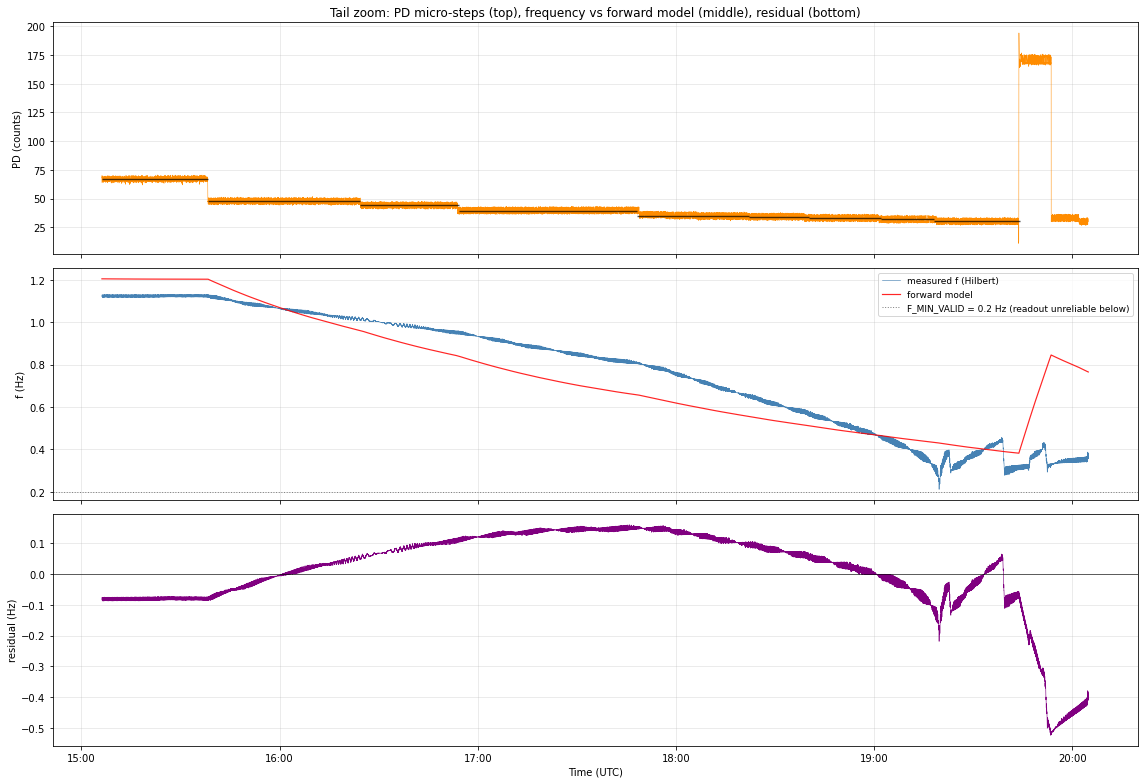

Reading this plot: if the disk responds to each micro-step, the red model curve
should track the blue data through each small level change with the residual
staying flat; a micro-step the disk did NOT respond to would show up as a step-
shaped feature appearing in the residual at that transition time. The late-run
excursion to PD~171 (~19:44 UTC, possibly a manual spin-up/down -- timing to be
checked against lab notes) is the largest and easiest response to verify.


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].plot(dts_tail, pd_tail, lw=0.5, color='darkorange')
for lv in fine_levels:
    axes[0].hlines(lv['pd'], gps_to_dt(lv['t0']), gps_to_dt(lv['t1']),
                   color='black', lw=1.4, alpha=0.7)
axes[0].set_ylabel('PD (counts)')
axes[0].set_title('Tail zoom: PD micro-steps (top), frequency vs forward model (middle), residual (bottom)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dts_tail, f_tail_d, lw=0.6, color='steelblue', label='measured f (Hilbert)')
axes[1].plot(dts_tail, fm_tail, lw=1.2, color='red', alpha=0.85, label='forward model')
axes[1].axhline(F_MIN_VALID, color='gray', ls=':', lw=1,
                label=f'F_MIN_VALID = {F_MIN_VALID} Hz (readout unreliable below)')
axes[1].set_ylabel('f (Hz)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(dts_tail, res_tail, lw=0.6, color='purple')
axes[2].axhline(0, color='black', lw=0.6)
axes[2].set_ylabel('residual (Hz)')
axes[2].set_xlabel('Time (UTC)')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

print("Reading this plot: if the disk responds to each micro-step, the red model curve")
print("should track the blue data through each small level change with the residual")
print("staying flat; a micro-step the disk did NOT respond to would show up as a step-")
print("shaped feature appearing in the residual at that transition time. The late-run")
print("excursion to PD~171 (~19:44 UTC, possibly a manual spin-up/down -- timing to be")
print("checked against lab notes) is the largest and easiest response to verify.")

## 7. Summary and Approximate Physical Units

In [12]:
print("=" * 92)
print("GLOBAL FORWARD MODEL -- SUMMARY")
print("=" * 92)
print(f"gamma (fixed)         : {GAMMA:.4e} /s  (tau = {TAU_FREE_MIN} min, from spindown_20260702)")
print(f"kappa                 : {kappa_pd:.4e} N*m per PD count")
print(f"PD0 (zero-torque PD)  : {PD0:.2f} counts  (pre-sequence PD level ~14)")
print(f"residual RMS          : {rms:.4f} Hz over {sel.sum():,} points")
print(f"gamma-scan preference : tau_best = {best_tau:.1f} min (free-decay value: {TAU_FREE_MIN} min)")

# Approximate conversion to physical units. The log's mW values are rough and the
# PD<->mW pairs are visibly non-monotonic, so this is indicative only -- kappa in
# PD units above is the defensible number.
pdv = np.array([p for p, _ in PD_MW_PAIRS])
mwv = np.array([m for _, m in PD_MW_PAIRS])
slope_pd_per_mw = np.polyfit(mwv, pdv, 1)[0]
scatter = np.std(pdv - np.polyval(np.polyfit(mwv, pdv, 1), mwv))
kappa_W = kappa_pd * slope_pd_per_mw * 1e3    # N*m per W

print(f"\nApprox PD/mW slope    : {slope_pd_per_mw:.1f} PD counts per mW "
      f"(fit scatter {scatter:.0f} counts -- large; log mW are rough)")
print(f"kappa (approx)        : {kappa_W:.3e} N*m per W")
print(f"force per W, both wings lit (torque = 2 F r_c) : {kappa_W/(2*R_C):.3e} N/W")
print(f"force per W, one wing lit   (torque = F r_c)   : {kappa_W/R_C:.3e} N/W")
print(f"radiation-pressure reference: P/c = {1/C_LIGHT:.3e} N/W (absorbing), "
      f"2P/c = {2/C_LIGHT:.3e} N/W (reflecting)")
print("\n(Which wing-geometry line applies depends on how the laser actually hits the")
print("disk -- one spot vs both wings -- still to be confirmed. Next step once kappa is")
print("trusted: convert the measured frequency noise vs averaging time into a minimum")
print("detectable power change vs integration time.)")

GLOBAL FORWARD MODEL -- SUMMARY
gamma (fixed)         : 2.4637e-04 /s  (tau = 67.65 min, from spindown_20260702)
kappa                 : 7.3499e-16 N*m per PD count
PD0 (zero-torque PD)  : 19.48 counts  (pre-sequence PD level ~14)
residual RMS          : 0.1962 Hz over 252,420 points
gamma-scan preference : tau_best = 160.0 min (free-decay value: 67.65 min)

Approx PD/mW slope    : 14.3 PD counts per mW (fit scatter 18 counts -- large; log mW are rough)
kappa (approx)        : 1.052e-11 N*m per W
force per W, both wings lit (torque = 2 F r_c) : 2.004e-09 N/W
force per W, one wing lit   (torque = F r_c)   : 4.007e-09 N/W
radiation-pressure reference: P/c = 3.336e-09 N/W (absorbing), 2P/c = 6.671e-09 N/W (reflecting)

(Which wing-geometry line applies depends on how the laser actually hits the
disk -- one spot vs both wings -- still to be confirmed. Next step once kappa is
trusted: convert the measured frequency noise vs averaging time into a minimum
detectable power change vs integratio